In [2]:
import os 
from dotenv import load_dotenv 
load_dotenv()

True

In [3]:
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [4]:
from langchain_openai import ChatOpenAI

llm= ChatOpenAI()

In [5]:
llm.invoke("Hi")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BkmAURzs4NZRyt4b47cUwGDRTvcrI', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--19ad6244-c753-4231-883e-0177795c497e-0', usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [13]:
from langchain_openai import OpenAIEmbeddings

embeddings= OpenAIEmbeddings(model="text-embedding-3-large")
embeddings

OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x000001ED43647230>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x000001ED436478C0>, model='text-embedding-3-large', dimensions=None, deployment='text-embedding-ada-002', openai_api_version=None, openai_api_base=None, openai_api_type=None, openai_proxy=None, embedding_ctx_length=8191, openai_api_key=SecretStr('**********'), openai_organization=None, allowed_special=None, disallowed_special=None, chunk_size=1000, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None, http_async_client=None, check_embedding_ctx_length=True)

In [14]:
embeddings.embed_query("Hi")

[-0.018819516524672508,
 0.005120374727994204,
 -0.011984202079474926,
 -0.017157532274723053,
 0.010379248298704624,
 0.014998584054410458,
 -0.007320058532059193,
 0.029003236442804337,
 0.008448414504528046,
 0.046633291989564896,
 -0.01688053458929062,
 -0.008961673825979233,
 -0.029850522056221962,
 0.002450203290209174,
 -0.051879946142435074,
 0.01570736989378929,
 0.017858171835541725,
 0.00013888049579691142,
 -0.00976007804274559,
 0.0017556734383106232,
 0.019617918878793716,
 0.020171914249658585,
 0.0008197895367629826,
 0.030225282534956932,
 0.01815146394073963,
 0.021915366873145103,
 -0.06605568528175354,
 -0.0010682722786441445,
 -0.058332353830337524,
 -0.02246936224400997,
 0.01273372396826744,
 0.03108886256814003,
 -0.007096016779541969,
 0.018966160714626312,
 0.03509717434644699,
 0.008815028704702854,
 0.026608025655150414,
 -0.021426549181342125,
 -0.04122370108962059,
 0.028449242934584618,
 0.029182469472289085,
 0.015300021506845951,
 -0.013075897470116615,

In [15]:
len(embeddings.embed_query("Hi"))

3072

In [16]:
url= "https://lilianweng.github.io/posts/2023-06-23-agent/"

In [17]:
from langchain_community.document_loaders import WebBaseLoader 

web_loader= WebBaseLoader(url)
data= web_loader.load()

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [18]:
data

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [20]:
data[0].metadata

{'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/',
 'title': "LLM Powered Autonomous Agents | Lil'Log",
 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\

In [23]:
data[0].metadata["description"]

'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-term memory: I would consider all the in-context learning (See Prompt Engineering) as utilizing short-term memory of the model 

In [24]:
data[0].page_content

'\n\n\n\n\n\nLLM Powered Autonomous Agents | Lil\'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil\'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ\n\n\n\n\n\n\n\n\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\n \n\n\nTable of Contents\n\n\n\nAgent System Overview\n\nComponent One: Planning\n\nTask Decomposition\n\nSelf-Reflection\n\n\nComponent Two: Memory\n\nTypes of Memory\n\nMaximum Inner Product Search (MIPS)\n\n\nComponent Three: Tool Use\n\nCase Studies\n\nScientific Discovery Agent\n\nGenerative Agents Simulation\n\nProof-of-Concept Examples\n\n\nChallenges\n\nCitation\n\nReferences\n\n\n\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The

In [25]:
urls= [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/"
]

In [29]:
[url for url in urls]

['https://lilianweng.github.io/posts/2023-06-23-agent/',
 'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/']

In [35]:
docs= [WebBaseLoader(url).load() for url in urls]
docs

[[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final res

In [42]:
[sublist for sublist in docs]

[[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final res

In [46]:
doc_list= [item for sublist in docs for item in sublist]
doc_list

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [48]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter= RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=100, chunk_overlap=50)
text_splitter

In [49]:
doc_splits= text_splitter.split_documents(doc_list)
doc_splits

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [50]:
len(doc_splits)

322

In [51]:
from langchain_community.vectorstores import Chroma

In [53]:
vectorstore= Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=embeddings
)

In [54]:
retriever= vectorstore.as_retriever()

In [55]:
retriever.invoke("what is agent and prompt?")

[Document(metadata={'description': 'Prompt Engineering, also known as In-Context Prompting, refers to methods for how to communicate with LLM to steer its behavior for desired outcomes without updating the model weights. It is an empirical science and the effect of prompt engineering methods can vary a lot among models, thus requiring heavy experimentation and heuristics.\nThis post only focuses on prompt engineering for autoregressive language models, so nothing with Cloze tests, image generation or multimodality models. At its core, the goal of prompt engineering is about alignment and model steerability. Check my previous post on controllable text generation.', 'title': "Prompt Engineering | Lil'Log", 'language': 'en', 'source': 'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/'}, page_content='Prompt Engineering, also known as In-Context Prompting, refers to methods for how to communicate with LLM to steer its behavior for desired outcomes without updating the mode

In [58]:
from langchain.tools.retriever import create_retriever_tool

In [61]:
retriever_tool= create_retriever_tool(
    retriever,
    "retriever_blog_post",
    """ 
    Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.
    You are a specialized assistant. Use the 'retriever_tool' **only** when the query explicitly relates to LangChain blog data. For all other queries, 
    respond directly without using any tool. For simple queries like 'hi', 'hello', or 'how are you', provide a normal response.
    """
)
retriever_tool

Tool(name='retriever_blog_post', description=" \n    Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.\n    You are a specialized assistant. Use the 'retriever_tool' **only** when the query explicitly relates to LangChain blog data. For all other queries, \n    respond directly without using any tool. For simple queries like 'hi', 'hello', or 'how are you', provide a normal response.\n    ", args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x000001ED3B6B7880>, retriever=VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001ED4616F610>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), document_separator='\n\n', response_format='content'), coroutine=func

In [62]:
tools= [retriever_tool]

In [64]:
from langgraph.prebuilt import ToolNode

In [65]:
retriever_node= ToolNode(tools)

In [66]:
retriever_node

tools(tags=None, recurse=True, explode_args=False, func_accepts_config=True, func_accepts={'store': ('__pregel_store', None)}, tools_by_name={'retriever_blog_post': Tool(name='retriever_blog_post', description=" \n    Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.\n    You are a specialized assistant. Use the 'retriever_tool' **only** when the query explicitly relates to LangChain blog data. For all other queries, \n    respond directly without using any tool. For simple queries like 'hi', 'hello', or 'how are you', provide a normal response.\n    ", args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x000001ED3B6B7880>, retriever=VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001ED4616F610>, search_kwargs={}), document_prompt=PromptTemplate(inpu

In [77]:
from typing import Literal, Sequence, Annotated, TypedDict
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import BaseMessage 
from langchain_core.prompts import PromptTemplate 
from langgraph.graph.message import add_messages

In [78]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [80]:
llm

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x000001ED36DDB0E0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001ED36DDBB60>, root_client=<openai.OpenAI object at 0x000001ED344F7380>, root_async_client=<openai.AsyncOpenAI object at 0x000001ED36DDB230>, model_kwargs={}, openai_api_key=SecretStr('**********'))

In [81]:
tools

[Tool(name='retriever_blog_post', description=" \n    Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.\n    You are a specialized assistant. Use the 'retriever_tool' **only** when the query explicitly relates to LangChain blog data. For all other queries, \n    respond directly without using any tool. For simple queries like 'hi', 'hello', or 'how are you', provide a normal response.\n    ", args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x000001ED3B6B7880>, retriever=VectorStoreRetriever(tags=['Chroma', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001ED4616F610>, search_kwargs={}), document_prompt=PromptTemplate(input_variables=['page_content'], input_types={}, partial_variables={}, template='{page_content}'), document_separator='\n\n', response_format='content'), coroutine=fun

In [83]:
llm_with_tool= llm.bind_tools(tools)

In [84]:
response= llm_with_tool.invoke("what is LLM Powered Autonomous Agents explain the planning and reflection and prompt engineering explain me in terms of agents and langchain?")

In [85]:
response.content

''

In [86]:
response.tool_calls

[{'name': 'retriever_blog_post',
  'args': {'query': 'LLM Powered Autonomous Agents'},
  'id': 'call_vYVQOWAfoAZY6xLITv4NRNg3',
  'type': 'tool_call'},
 {'name': 'retriever_blog_post',
  'args': {'query': 'prompt engineering'},
  'id': 'call_CbBY6abQO1Fp57uoXIcDdnBR',
  'type': 'tool_call'}]

In [ ]:
# def LLM_Decision_Maker(state:AgentState):
#     print("----CALL LLM_DECISION_MAKE----")
#     message=state["messages"]
    
#     if len(message)>1:
#         last_message=message[-1]
#         question=last_message.content
        
#         prompt=PromptTemplate(
#         template="""You are a helpful assistant whatever question has been asked to find out that in the given question and answer.
#                         Here is the question:{question}
#                         """,
#                         input_variables=["question"]
#                         )
#         chain=prompt | llm
#         response=chain.invoke({"question":question})
#         return {"messages":[response]}
#     else:
#         llm_with_tool=llm.bind_tools(tools)
#         response=llm_with_tool.invoke(message)
#         return {"messages":[response]}

In [161]:
def LLM_Decision_Maker(state: AgentState):
    print("----CALL LLM_DECISION_MAKE----")

    message=state["messages"]
    last_message= message[-1]

    question= last_message.content
    response= llm_with_tool.invoke(question)
    
    return {"messages":[response]}

In [123]:
from langchain.pydantic_v1 import BaseModel, Field

In [124]:
class Grade(BaseModel):
    binary_score: str = Field(description="Relvance score 'yes' or 'no'")

In [125]:
from typing import Literal
#we use it for type of hinting

In [ ]:
def grade_documents(state: AgentState):
    print("----CALLING GRADE FOR CHECKING RELEVANCY----")

    llm_with_structure_op= llm.with_structured_output(Grade)
    
    prompt= PromptTemplate(
        template="""You are a grader deciding if a document is relevant to a user’s question.
                    Here is the document: {context}
                    Here is the user’s question: {question}
                    If the document talks about or contains information related to the user’s question, mark it as relevant. 
                    Give a 'yes' or 'no' answer to show if the document is relevant to the question.""",
                    input_variables=["context", "question"]
                    )
     
    chain= prompt | llm_with_structure_op

    message= state['messages']
    last_message = message[-1]
    
    question= message[0].content
    docs= last_message.content
    
    scored_result= chain.invoke({"question": question, "context": docs})
    
    score= scored_result.binary_score
     
    if score=="yes":
        print("----DECISION: DOCS ARE RELEVANT----")
        return "generator"
    else:
        print("----DECISION: DOCS ARE NOT RELEVANT----")
        return "rewriter"

In [127]:
from langchain import hub

In [128]:
hub.pull("rlm/rag-prompt").pretty_print()

================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [163]:
def generate(state: AgentState):
    print("----RAG OUTPUT GENERATE----")
    
    message= state["messages"]
    question= message[0].content
    
    last_message= message[-1]
    docs= last_message.content
    
    prompt= hub.pull("rlm/rag-prompt")
    
    rag_chain= prompt | llm
    
    response= rag_chain.invoke({"context": docs, "question": question})
    
    print(f"this is my response:{response}")
    
    return {"messages": [response]}

In [158]:
from langchain_core.messages import HumanMessage

In [164]:
def rewrite(state: AgentState):
    print("----TRANSFORM QUERY----")

    message= state["messages"]
    question= message[0].content
    
    input= [HumanMessage(content=f"""Look at the input and try to reason about the underlying semantic intent or meaning. 
                    Here is the initial question: {question} 
                    Formulate an improved question: """)
       ]

    response= llm.invoke(input)
    
    return {"messages": [response]}

In [165]:
workflow= StateGraph(AgentState)

In [166]:
workflow.add_node("LLM Decision Maker", LLM_Decision_Maker)
workflow.add_node("Vector Retriever", retriever_node)
workflow.add_node("Output Generator", generate)
workflow.add_node("Query Rewriter",rewrite)

In [167]:
workflow.add_edge(START, "LLM Decision Maker")

In [168]:
from langgraph.prebuilt import tools_condition 

In [169]:
workflow.add_conditional_edges(
    "LLM Decision Maker",
    tools_condition,
    {
        "tools": "Vector Retriever",
        END: END
    }
)

In [170]:
workflow.add_conditional_edges(
    "Vector Retriever",
    grade_documents,
    {
        "generator": "Output Generator",
        "rewriter": "Query Rewriter"
    }
)

In [171]:
workflow.add_edge("Query Rewriter", "LLM Decision Maker")

In [172]:
workflow.add_edge("Output Generator", END)

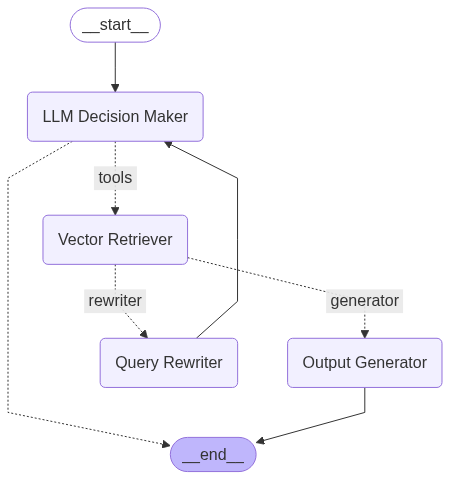

In [152]:
workflow.compile()

In [174]:
app= workflow.compile()

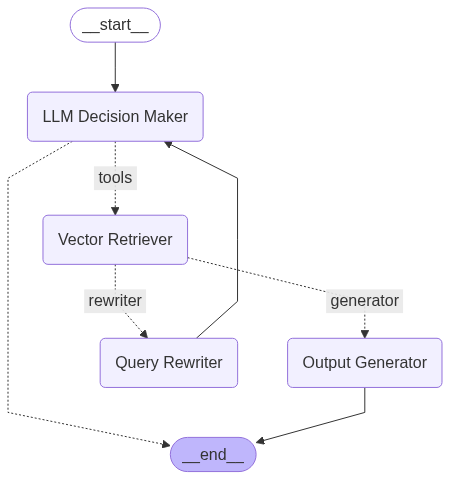

In [154]:
from IPython.display import Image, display 

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [175]:
app.invoke({"messages": ["what is LLM Powered Autonomous Agents explain the planning and reflection and prompt engineering explain me in terms of agents and langchain?"]})

----CALL LLM_DECISION_MAKE----
----CALLING GRADE FOR CHECKING RELEVANCY----


c:\Users\Satish\OneDrive\AgenticAI\AgenticAI2.0\venv\Lib\site-packages\langchain_openai\chat_models\base.py:1656: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or specify schema via JSON Schema or Pydantic V2 BaseModel. Overriding to method="function_calling".
  warnings.warn(
c:\Users\Satish\OneDrive\AgenticAI\AgenticAI2.0\venv\Lib\site-packages\langchain_openai\chat_models\base.py:1669: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


----DECISION: DOCS ARE NOT RELEVANT----
----TRANSFORM QUERY----
----CALL LLM_DECISION_MAKE----
----CALLING GRADE FOR CHECKING RELEVANCY----


c:\Users\Satish\OneDrive\AgenticAI\AgenticAI2.0\venv\Lib\site-packages\langchain_openai\chat_models\base.py:1656: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or specify schema via JSON Schema or Pydantic V2 BaseModel. Overriding to method="function_calling".
  warnings.warn(
c:\Users\Satish\OneDrive\AgenticAI\AgenticAI2.0\venv\Lib\site-packages\langchain_openai\chat_models\base.py:1669: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


----DECISION: DOCS ARE RELEVANT----
----RAG OUTPUT GENERATE----
this is my response:content='LLM Powered Autonomous Agents are agents using a large language model as the core controller. Planning and reflection involve integrating tools and reasoning approaches within the LangChain framework to enable problem-solving abilities in various domains. Engineering such agents involves combining Chain of Thought prompting with tools tailored to specific tasks for effective problem-solving capabilities.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 367, 'total_tokens': 428, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BkrKBOFjaPmsVH1lDYocyLIbdW1c9', 'service_tier': 'default', 'finish_reason

{'messages': [HumanMessage(content='what is LLM Powered Autonomous Agents explain the planning and reflection and prompt engineering explain me in terms of agents and langchain?', additional_kwargs={}, response_metadata={}, id='daa51108-b0da-4c19-89f0-dfb0f44b3c6c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_m4CguLN0URSzprZOhn1gGwR0', 'function': {'arguments': '{"query": "LLM Powered Autonomous Agents"}', 'name': 'retriever_blog_post'}, 'type': 'function'}, {'id': 'call_nwIGj4VcL1sfrnJoZ4nO4cuW', 'function': {'arguments': '{"query": "prompt engineering"}', 'name': 'retriever_blog_post'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 166, 'total_tokens': 220, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turb

In [176]:
import warnings
warnings.filterwarnings("ignore")

In [177]:
input= "what is LLM Powered Autonomous Agents explain the planning and reflection and prompt engineering explain me in terms of agents and langchain?"
state= {"messages": [input]}
state

{'messages': ['what is LLM Powered Autonomous Agents explain the planning and reflection and prompt engineering explain me in terms of agents and langchain?']}

In [180]:
app.invoke(state)

----CALL LLM_DECISION_MAKE----
----CALLING GRADE FOR CHECKING RELEVANCY----
----DECISION: DOCS ARE NOT RELEVANT----
----TRANSFORM QUERY----
----CALL LLM_DECISION_MAKE----
----CALLING GRADE FOR CHECKING RELEVANCY----
----DECISION: DOCS ARE RELEVANT----
----RAG OUTPUT GENERATE----
this is my response:content='LLM Powered Autonomous Agents involve components such as planning and reflection. Planning includes task decomposition while self-reflection is a crucial aspect. Memory types and Maximum Inner Product Search (MIPS) are essential for these agents in the langchain framework.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 278, 'total_tokens': 326, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': '

{'messages': [HumanMessage(content='what is LLM Powered Autonomous Agents explain the planning and reflection and prompt engineering explain me in terms of agents and langchain?', additional_kwargs={}, response_metadata={}, id='2a1e5ae6-e92f-4585-8658-dd7f2b8e97d5'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_Bssj7RGUxIh8R9VtTYeewLyF', 'function': {'arguments': '{"query": "LLM Powered Autonomous Agents"}', 'name': 'retriever_blog_post'}, 'type': 'function'}, {'id': 'call_2P91olDnkCzpmZckYHs4J41s', 'function': {'arguments': '{"query": "Planning and Reflection in LLMs"}', 'name': 'retriever_blog_post'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 166, 'total_tokens': 225, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 

In [181]:
app.invoke({"messages": ["hi how are you gpt?"]})

----CALL LLM_DECISION_MAKE----


{'messages': [HumanMessage(content='hi how are you gpt?', additional_kwargs={}, response_metadata={}, id='48507f8c-6bf5-4ce4-8be9-a06da982ad8e'),
  AIMessage(content="Hello! I'm here and ready to assist you. How can I help you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 148, 'total_tokens': 167, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BkrPUSjG25Kw0Y18VHupjIAvMV3oP', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--5c11f7c3-25c4-4189-9987-9dbf5133dcb1-0', usage_metadata={'input_tokens': 148, 'output_tokens': 19, 'total_tokens': 167, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}

In [182]:
app.invoke({"messages":["what is a capital of india?"]})

----CALL LLM_DECISION_MAKE----


{'messages': [HumanMessage(content='what is a capital of india?', additional_kwargs={}, response_metadata={}, id='f7527997-4088-45c2-90d3-5b2e57654be8'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 148, 'total_tokens': 157, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BkrQ1KVgSnA6AdAWXYvvud2hITwGI', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--6d91297c-769d-400f-a16f-97eb7a470ebf-0', usage_metadata={'input_tokens': 148, 'output_tokens': 9, 'total_tokens': 157, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [184]:
question= "can you explain me what is a task decomposition and why Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks?"

app.invoke({"messages": [question]})

----CALL LLM_DECISION_MAKE----
----CALLING GRADE FOR CHECKING RELEVANCY----
----DECISION: DOCS ARE RELEVANT----
----RAG OUTPUT GENERATE----
this is my response:content="Task decomposition is breaking down a complex task into smaller, more manageable subgoals. Chain of thought (CoT) is a standard prompting technique that enhances model performance by instructing the model to think step by step, helping to decompose difficult tasks into simpler steps and improve performance on complex tasks. This technique allows the model to utilize more computation at test time and shed light on the model's thinking process." additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 347, 'total_tokens': 428, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 's

{'messages': [HumanMessage(content='can you explain me what is a task decomposition and why Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks?', additional_kwargs={}, response_metadata={}, id='d82c915b-031d-4710-9da3-9c29420ad19b'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_IVLBg6pVlLbMP2H2oMolrgSo', 'function': {'arguments': '{"query":"task decomposition"}', 'name': 'retriever_blog_post'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 181, 'total_tokens': 199, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BkrRXudsDZsaw6sKc3PAaB3YqLAnp', 'service_tier': 'default', 'finish_

Assignment: 5

1. take multiple data sources and complex data sources
1. strict your prompting in every node based on your desired output
1. check question and generated docuemnt(k=keep more than 5 with strict prompting according to your usecase)

what is a main aim of this agentic rag? answer: to provide more security and more validation and more determenstic flow to the RAG?

Assignment: 6

#### **As a homework now try it out this one: Corrective RAG(Type of the Agentic RAG)**

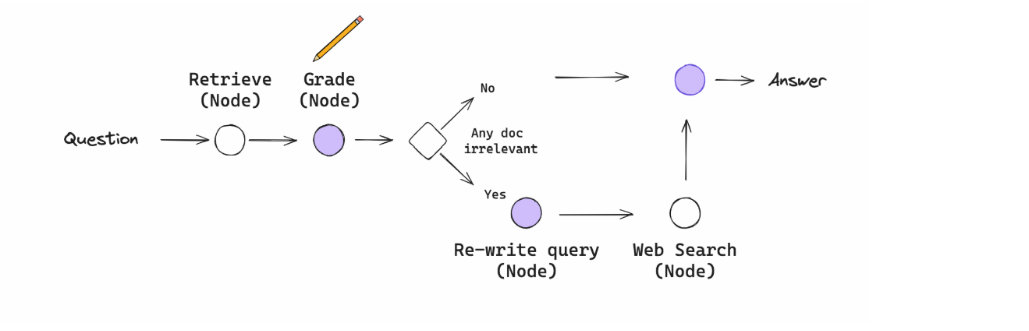